# Uzbek-Language Telegram Job Market in South Korea

This notebook measures the advertised Uzbek-speaking Telegram job market. It describes advertisements, not the entire Korean labor market, and does not infer individual workers' legal status.

In [22]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "tdlib").is_dir():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find the project root")

In [13]:
import json
import pandas as pd
from pathlib import Path


def find_raw_path() -> Path:
    for candidate in (Path("data/raw"), Path("../../data/raw")):
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/raw")


def extract_chat_id(message: dict) -> int | None:
    chat_id = message.get("chat_id")
    if isinstance(chat_id, int):
        return chat_id
    peer_id = message.get("peer_id")
    if isinstance(peer_id, dict):
        for key in ("channel_id", "chat_id", "user_id"):
            if isinstance(peer_id.get(key), int):
                return peer_id[key]
    return None


DATASET_PATH = find_raw_path()
records = []

for source_path in sorted(DATASET_PATH.glob("*.jsonl")):
    with source_path.open("r", encoding="utf-8") as source:
        for line_number, line in enumerate(source, start=1):
            try:
                message = json.loads(line)
            except json.JSONDecodeError:
                continue
            text = str(message.get("message", "")).strip()
            records.append(
                {
                    "source_group": source_path.stem,
                    "source_file": source_path.name,
                    "source_line": line_number,
                    "msg_id": message.get("id"),
                    "chat_id": extract_chat_id(message),
                    "message_user_id": message.get("sender_id"),
                    "date": pd.to_datetime(message.get("date"), unit="s", utc=True, errors="coerce"),
                    "text": text,
                }
            )

messages = pd.DataFrame(records)
if messages.empty:
    raise ValueError(f"No JSONL messages found in {DATASET_PATH}")

messages["month"] = messages["date"].dt.to_period("M").astype("string")
messages["year"] = messages["date"].dt.year.astype("Int64")
messages["is_duplicate"] = messages.duplicated(["chat_id", "msg_id"], keep="first")
unique_messages = messages.loc[~messages["is_duplicate"]].copy()

print(f"Raw advertisements: {len(messages):,}")
print(f"Unique advertisements: {len(unique_messages):,}")
print(f"Duplicate rows: {messages['is_duplicate'].sum():,}")
unique_messages.head(3)

Raw advertisements: 226,016
Unique advertisements: 226,016
Duplicate rows: 0


/var/folders/zw/s4120bc94vdcwd8bd80yw_j80000gn/T/ipykernel_73209/1462799952.py:53: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  messages["month"] = messages["date"].dt.to_period("M").astype("string")


,source_group,source_file,source_line,msg_id,chat_id,message_user_id,date,text,month,year,is_duplicate
0,group_-1001141152967,group_-1001141152967.jsonl,1,51260,1141152967,None,2026-09-24 13:18:56+00:00,Xamirli taomlar tayyorlash bo‘yicha povar kera...,2026-09,2026,False
1,group_-1001141152967,group_-1001141152967.jsonl,2,51259,1141152967,None,2026-09-24 11:00:01+00:00,Sheriklikga 2 kishi bor,2026-09,2026,False
2,group_-1001141152967,group_-1001141152967.jsonl,3,51258,1141152967,None,2026-09-24 08:15:19+00:00,Hozir,2026-09,2026,False


In [14]:
import re

In [15]:
LOCATION_KEYWORDS = {
    "Seoul": ["seoul", "서울", "seul"],
    "Gyeonggi": ["gyeonggi", "경기", "gyeonggido", "kyongido"],
    "Incheon": ["incheon", "인천"],
    "Busan": ["busan", "부산"],
    "Chungnam": ["chungnam", "충남", "cheonan", "천안"],
    "Mokpo": ["mokpo", "목포"],
    "Daegu": ["daegu", "대구", "tegu"],
    "Daejeon": ["daejeon", "대전"],
    "Jeju": ["jeju", "제주"],
}

OCCUPATION_KEYWORDS = {
    "factory": ["factory", "zavod", "공장", "생산"],
    "restaurant": ["restaurant", "restoran", "식당", "주방", "주방장"],
    "construction": ["construction", "qurilish", "건설", "현장"],
    "agriculture": ["farm", "ferma", "농장", "농업", "dalada"],
    "warehouse": ["warehouse", "ombor", "물류", "창고"],
    "delivery": ["delivery", "배달", "쿠팡"],
    "cleaning": ["cleaning", "tozalash", "청소"],
}

VISA_PATTERN = re.compile(r"\b(?:E[- ]?9|H[- ]?2|F[- ]?[46]|D[- ]?2|E[- ]?7|E[- ]?8)\b", re.IGNORECASE)
SALARY_PATTERN = re.compile(r"(?P<amount>\d{1,3}(?:[,.]\d{3})+|\d{4,})\s*(?:won|원)", re.IGNORECASE)


def matching_labels(text: str, keywords: dict[str, list[str]]) -> str:
    lowered = text.lower()
    return ";".join(label for label, terms in keywords.items() if any(term.lower() in lowered for term in terms))


def extract_salary(text: str) -> tuple[int | None, str]:
    match = SALARY_PATTERN.search(text)
    if not match:
        return None, ""
    amount = int(match.group("amount").replace(",", "").replace(".", ""))
    context = text[max(0, match.start() - 30):match.end() + 30].lower()
    if any(term in context for term in ("hour", "soat", "시급", "시간")):
        period = "hourly"
    elif any(term in context for term in ("day", "kun", "일급", "하루")):
        period = "daily"
    elif any(term in context for term in ("month", "oylik", "월급", "월")):
        period = "monthly"
    else:
        period = "unknown"
    return amount, period


def enrich(row: pd.Series) -> pd.Series:
    salary, salary_period = extract_salary(row["text"])
    return pd.Series(
        {
            "locations": matching_labels(row["text"], LOCATION_KEYWORDS),
            "occupations": matching_labels(row["text"], OCCUPATION_KEYWORDS),
            "visa_statuses": ";".join(sorted(set(VISA_PATTERN.findall(row["text"])), key=str.lower)),
            "salary_krw": salary,
            "salary_period": salary_period,
            "has_accommodation": any(term in row["text"].lower() for term in ("숙소", "기숙사", "accommodation", "yotoqxona")),
            "has_meals": any(term in row["text"].lower() for term in ("식사", "밥 제공", "meal", "ovqat")),
            "requires_korean": any(term in row["text"].lower() for term in ("한국어", "korean", "koreys tili")),
        }
    )


features = unique_messages.join(unique_messages.apply(enrich, axis=1))
features[["locations", "occupations", "visa_statuses", "salary_period"]].head()

,locations,occupations,visa_statuses,salary_period
0,,,,
1,,,,
2,,,,
3,,,,
4,,,,


In [16]:
def canonicalize_visa(value: str) -> str:
    return re.sub(r"[-\s]", "", value).upper()


features["visa_statuses"] = features["visa_statuses"].apply(
    lambda value: ";".join(sorted({canonicalize_visa(item) for item in value.split(";") if item}))
)
features["visa_statuses"].value_counts().head(10)

visa_statuses
               219506
E9               2104
D2               1401
D2;E9             484
F4;F6             354
D2;E9;F4;F6       263
E7                248
H2                226
E7;E9             180
D2;E7;E9          175
Name: count, dtype: int64

In [17]:
def exploded_counts(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    values = frame[[column]].assign(label=frame[column].str.split(";")).explode("label")
    values = values[values["label"].notna() & values["label"].ne("")]
    return values.groupby("label").size().sort_values(ascending=False).rename("advertisements").to_frame()


print("Advertisements by month")
display(features.groupby("month").size().rename("advertisements").to_frame())

print("Advertisements by location")
display(exploded_counts(features, "locations"))

print("Advertisements by occupation")
display(exploded_counts(features, "occupations"))

print("Advertisements by advertised visa status")
display(exploded_counts(features, "visa_statuses"))

print("Median salary by period")
display(
    features.dropna(subset=["salary_krw"])
    .groupby("salary_period")["salary_krw"]
    .agg(advertisements="size", median_krw="median")
    .sort_values("advertisements", ascending=False)
)

print("Location x occupation")
location_occupation = (
    features.assign(location=features["locations"].str.split(";"), occupation=features["occupations"].str.split(";"))
    .explode("location")
    .explode("occupation")
    .reset_index(drop=True)
)
location_occupation = location_occupation.dropna(subset=["location", "occupation"])
display(pd.crosstab(location_occupation["location"], location_occupation["occupation"]))

Advertisements by month


,advertisements
month,
2021-01,144
2021-02,392
2021-03,2028
2021-04,780
2021-05,666
...,...
2026-06,5155
2026-07,5293
2026-08,15860


Advertisements by location


,advertisements
label,
Mokpo,6081
Incheon,5241
Seoul,5175
Daegu,4774
Gyeonggi,4088
Chungnam,2817
Busan,1324
Daejeon,1304
Jeju,95


Advertisements by occupation


...

,advertisements
label,
E9,3549
D2,2879
F4,1416
F6,1062
H2,814
E7,775
E8,18


Median salary by period


,advertisements,median_krw
salary_period,,
unknown,2692,98000.0
hourly,1178,140000.0
daily,736,152000.0
monthly,310,105000.0


Location x occupation


occupation,,agriculture,cleaning,construction,delivery,factory,restaurant,warehouse
location,,,,,,,,
,193564,150,166,308,28,5030,198,176
Busan,1174,3,12,14,0,125,4,0
Chungnam,2563,8,6,4,0,237,2,12
Daegu,4404,10,32,6,3,311,14,1
Daejeon,1255,4,5,5,0,33,3,1
Gyeonggi,3814,6,12,28,5,225,4,32
Incheon,5078,1,21,12,0,114,3,14
Jeju,85,0,0,0,0,7,3,0
Mokpo,5915,12,12,16,0,123,11,2


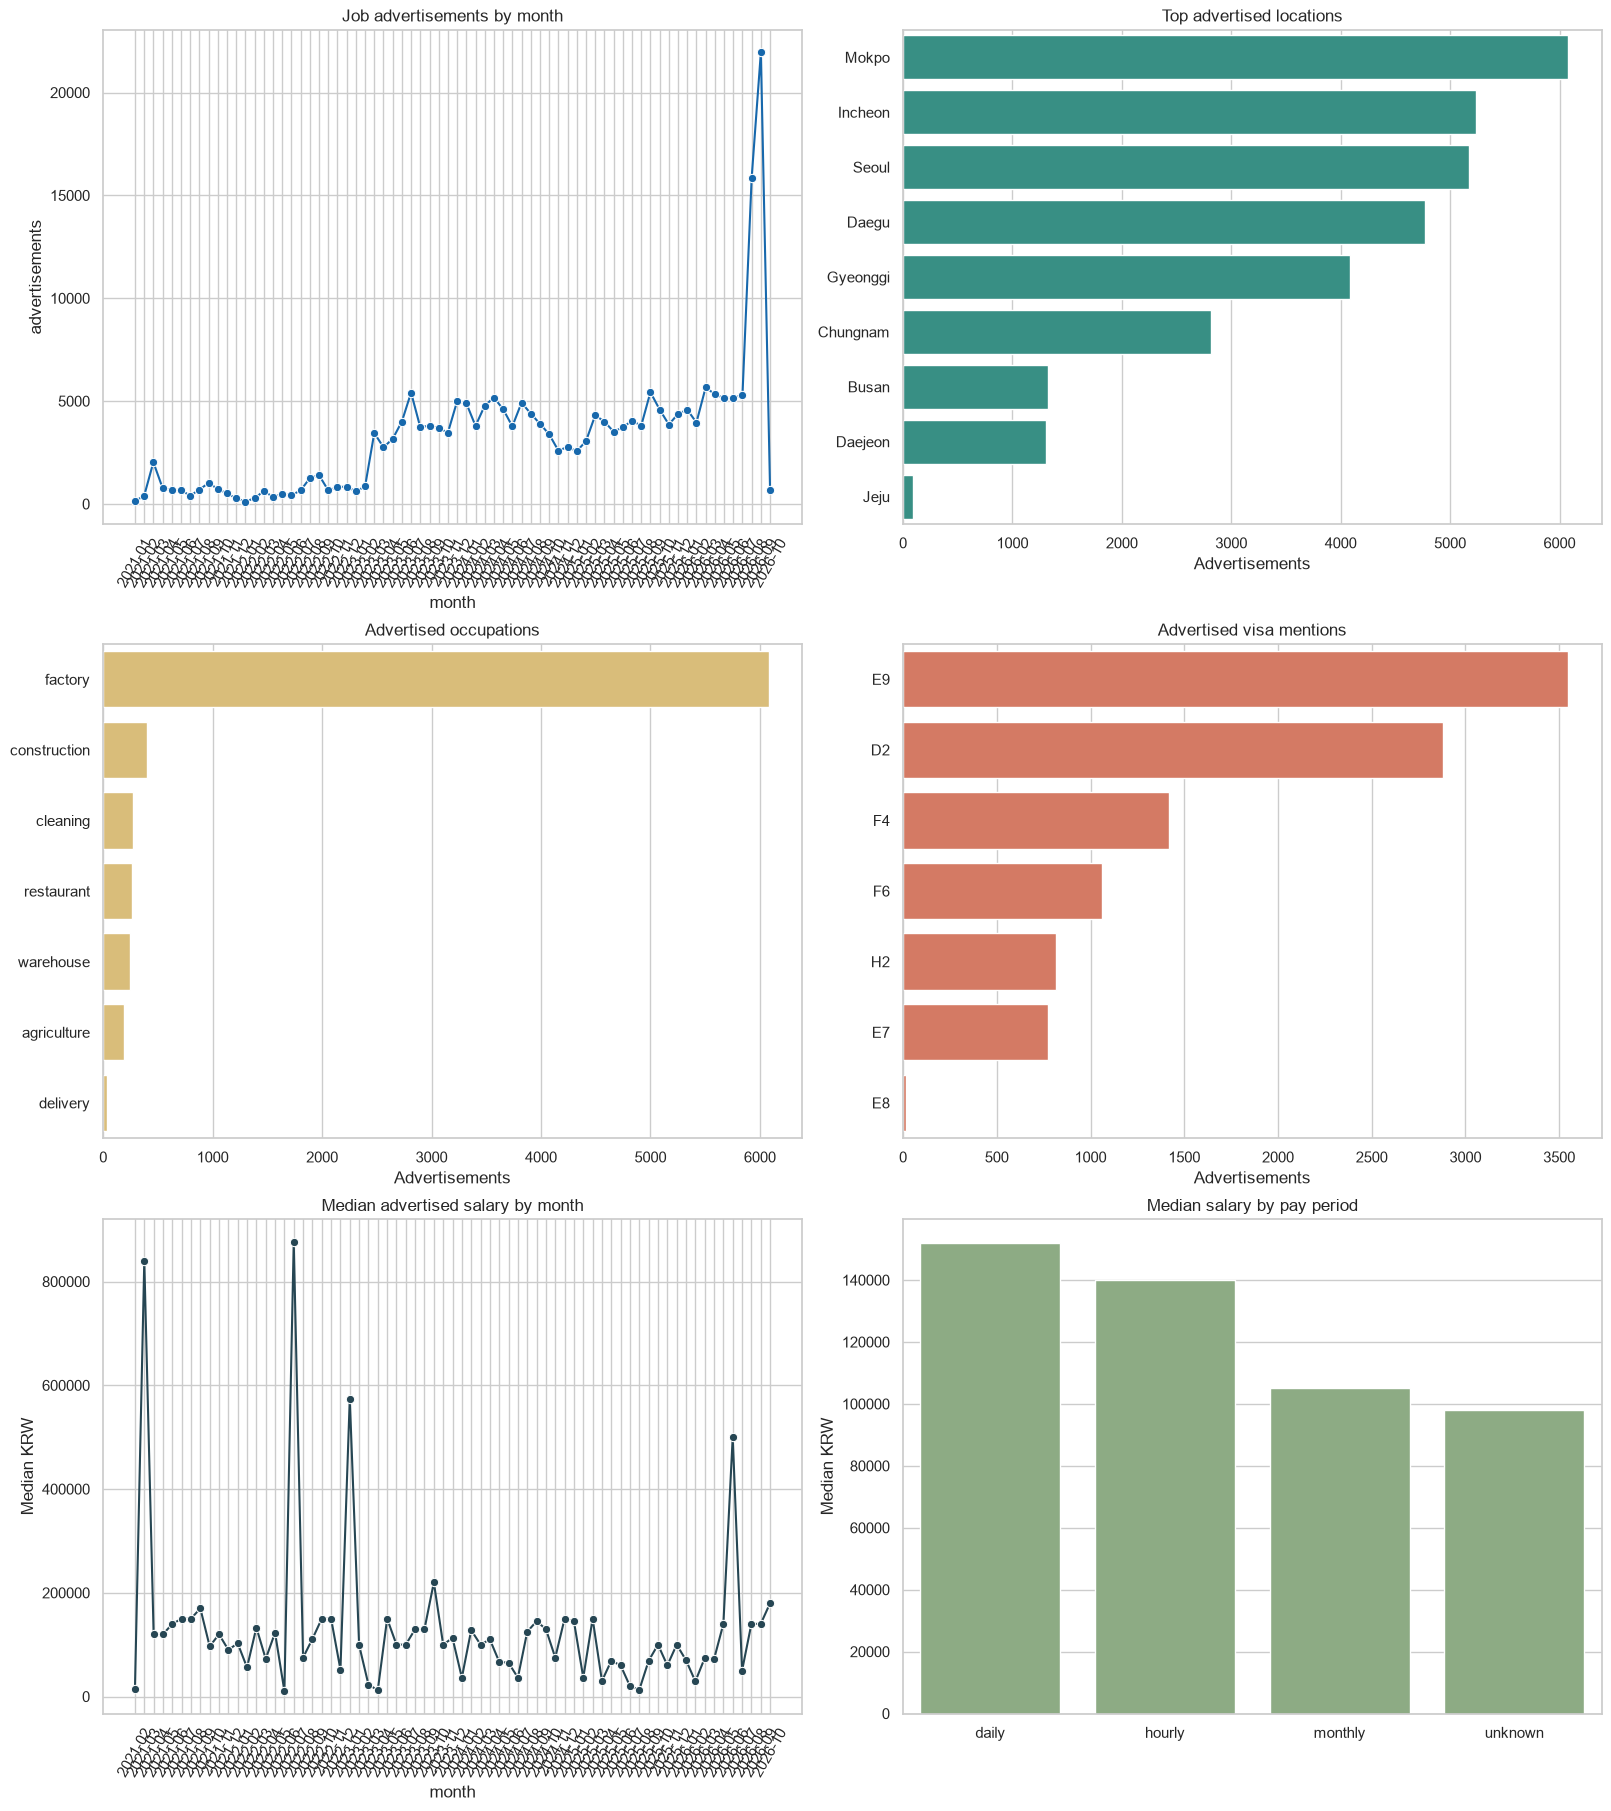

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

monthly = features.groupby("month").size().rename("advertisements").reset_index()
location_counts = exploded_counts(features, "locations").head(10).reset_index()
occupation_counts = exploded_counts(features, "occupations").reset_index()
visa_counts = exploded_counts(features, "visa_statuses").head(10).reset_index()
salary_monthly = (
    features.dropna(subset=["salary_krw"])
    .groupby("month", as_index=False)["salary_krw"]
    .median()
)

fig, axes = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)

sns.lineplot(data=monthly, x="month", y="advertisements", marker="o", ax=axes[0, 0], color="#1768ac")
axes[0, 0].set_title("Job advertisements by month")
axes[0, 0].tick_params(axis="x", rotation=60)

sns.barplot(data=location_counts, y="label", x="advertisements", ax=axes[0, 1], color="#2a9d8f")
axes[0, 1].set_title("Top advertised locations")
axes[0, 1].set_xlabel("Advertisements")
axes[0, 1].set_ylabel("")

sns.barplot(data=occupation_counts, y="label", x="advertisements", ax=axes[1, 0], color="#e9c46a")
axes[1, 0].set_title("Advertised occupations")
axes[1, 0].set_xlabel("Advertisements")
axes[1, 0].set_ylabel("")

sns.barplot(data=visa_counts, y="label", x="advertisements", ax=axes[1, 1], color="#e76f51")
axes[1, 1].set_title("Advertised visa mentions")
axes[1, 1].set_xlabel("Advertisements")
axes[1, 1].set_ylabel("")

sns.lineplot(data=salary_monthly, x="month", y="salary_krw", marker="o", ax=axes[2, 0], color="#264653")
axes[2, 0].set_title("Median advertised salary by month")
axes[2, 0].set_ylabel("Median KRW")
axes[2, 0].tick_params(axis="x", rotation=60)

salary_period = (
    features.dropna(subset=["salary_krw"])
    .groupby("salary_period", as_index=False)["salary_krw"]
    .median()
)
sns.barplot(data=salary_period, x="salary_period", y="salary_krw", ax=axes[2, 1], color="#8ab17d")
axes[2, 1].set_title("Median salary by pay period")
axes[2, 1].set_ylabel("Median KRW")
axes[2, 1].set_xlabel("")

plt.show()

In [28]:
from src.preprocess import load_messages, build_preprocessor

messages = load_messages(DATASET_PATH, True)               

In [ ]:
preprocessor = build_preprocessor()

transformed_messages = preprocessor.fit_transform(messages[:10][["text", "source_file"]])
print(transformed_messages) 

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 789 stored elements and shape (10, 199)>
  Coords	Values
  (0, 3)	0.5828575057876106
  (0, 4)	0.81257438302413
  (0, 10)	0.1357526316595407
  (0, 11)	0.08679629209021045
  (0, 12)	0.1193868391349873
  (0, 22)	0.1193868391349873
  (0, 23)	0.11733736305893554
  (0, 24)	0.13065699061187802
  (0, 25)	0.13065699061187802
  (0, 26)	0.11733736305893554
  (0, 27)	0.08679629209021045
  (0, 28)	0.06265006352869759
  (0, 29)	0.0771681234283886
  (0, 32)	0.21543483930376317
  (0, 33)	0.08679629209021045
  (0, 34)	0.08679629209021045
  (0, 35)	0.08679629209021045
  (0, 36)	0.14463095630132408
  (0, 41)	0.13065699061187802
  (0, 48)	0.11733736305893554
  (0, 49)	0.14695889723559732
  (0, 51)	0.1808375357006895
  (0, 52)	0.11733736305893554
  (0, 53)	0.056888468527341224
  (0, 57)	0.0771681234283886
  :	:
  (9, 134)	0.07823678174219977
  (9, 135)	0.20415402442492808
  (9, 138)	0.09765443968509008
  (9, 139)	0.06351766932596531
  (9, 140)	0

In [32]:
preprocessor

TypeError: len() of unsized object

TypeError: len() of unsized object

ColumnTransformer(sparse_threshold=1.0,
                  transformers=[('words',
                                 Pipeline(steps=[('functiontransformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function _bodies at 0x11818e140>)),
                                                 ('textcleaner',
                                                  TextCleaner(mask_numbers=True)),
                                                 ('tfidfvectorizer',
                                                  TfidfVectorizer(max_features=50000,
                                                                  min_df=3,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True))])